In [19]:
# yfinanceが入ってるか,またそのバージョンを確認したい。
# もし入っていなければ、インストールする。
# もし入っているが、バージョンが古い場合は、アップデートする。
# もし入っているが、バージョンが新しい場合は、何もしない。
import subprocess
import sys
import pkg_resources
import importlib
def check_and_install(package_name, required_version):
    try:
        # パッケージがインストールされているか確認
        pkg = importlib.import_module(package_name)
        installed_version = pkg_resources.get_distribution(package_name).version
        print(f"{package_name} is already installed. Version: {installed_version}")
        
        # バージョンを比較
        if pkg_resources.parse_version(installed_version) < pkg_resources.parse_version(required_version):
            print(f"Updating {package_name} to version {required_version}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", f"{package_name}>={required_version}"])
        else:
            print(f"{package_name} is up to date.")
    except ImportError:
        print(f"{package_name} is not installed. Installing version {required_version}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", f"{package_name}>={required_version}"])
# yfinanceのバージョンを指定
required_version = "0.2.79"
check_and_install("yfinance", required_version)


yfinance is already installed. Version: 1.2.0
yfinance is up to date.


In [20]:
# !pip install yfinance==0.2.61

In [21]:
import yfinance as yf

In [40]:
# yf.download(対象の株銘柄, 期間, 頻度)

ticker = "AMZN" # Amazonの株価を取得するためのティッカーシンボル

df = yf.download(ticker, period="6mo", interval="1d") # 6ヶ月分のデータを1日ごとに取得
df.head() # データの最初の5行を表示

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2025-09-16,234.050003,235.899994,232.229996,232.940002,38203900
2025-09-17,231.619995,234.300003,228.710007,233.770004,42815200
2025-09-18,231.229996,233.479996,228.789993,232.500000,37931700
2025-09-19,231.479996,234.160004,229.699997,232.369995,97943200
2025-09-22,227.630005,230.570007,227.509995,230.559998,45914500


In [ ]:

df.columns = ["Close", "High", "Low", "Open", "Volume"] # 列の順番を変更
df.head() # データの最初の5行を表示

,Close,High,Low,Open,Volume
Date,,,,,
2025-09-15,231.429993,233.729996,230.320007,230.630005,33243300
2025-09-16,234.050003,235.899994,232.229996,232.940002,38203900
2025-09-17,231.619995,234.300003,228.710007,233.770004,42815200
2025-09-18,231.229996,233.479996,228.789993,232.500000,37931700
2025-09-19,231.479996,234.160004,229.699997,232.369995,97943200


In [24]:
# yf.download(対象の株銘柄, 期間, 頻度)

ticker = "4755.T" # 楽天の株価を取得するためのティッカーシンボル

df = yf.download(ticker, period="6mo", interval="1d")
df.columns = ["Close", "High", "Low", "Open", "Volume"]
df

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2025-09-16,974.299988,976.500000,956.500000,974.900024,20629600
2025-09-17,990.200012,1012.000000,968.200012,975.000000,30937500
2025-09-18,995.000000,1002.500000,981.000000,983.000000,16808000
2025-09-19,990.500000,1009.000000,973.599976,999.799988,25624200
2025-09-22,964.400024,997.000000,964.400024,996.000000,17075600
...,...,...,...,...,...
2026-03-09,786.299988,786.700012,761.200012,762.799988,23479500
2026-03-10,799.500000,799.799988,784.400024,792.000000,16838900
2026-03-11,798.099976,813.700012,796.000000,805.299988,10550800


In [25]:
# yf.download(対象の株銘柄, 期間, 頻度)

ticker = ["AMZN", "4755.T"] 

df = yf.download(ticker, period="6mo", interval="1d")
# df.columns = ["Close", "High", "Low", "Open", "Volume"]
df

[*********************100%***********************]  2 of 2 completed


Price            Close                     High                     Low  \
Ticker          4755.T        AMZN       4755.T        AMZN      4755.T   
Date                                                                      
2025-09-15         NaN  231.429993          NaN  233.729996         NaN   
2025-09-16  974.299988  234.050003   976.500000  235.899994  956.500000   
2025-09-17  990.200012  231.619995  1012.000000  234.300003  968.200012   
2025-09-18  995.000000  231.229996  1002.500000  233.479996  981.000000   
2025-09-19  990.500000  231.479996  1009.000000  234.160004  973.599976   
...                ...         ...          ...         ...         ...   
2026-03-09  786.299988  213.490005   786.700012  213.820007  761.200012   
2026-03-10  799.500000  214.330002   799.799988  215.649994  784.400024   
2026-03-11  798.099976  212.649994   813.700012  217.000000  796.000000   
2026-03-12  783.599976  209.529999   793.000000  211.710007  776.000000   
2026-03-13  765.500000  207.669998   779.599976  210.559998  764.400024   

Price                         Open                  Volume              
Ticker            AMZN      4755.T        AMZN      4755.T        AMZN  
Date                                                                    
2025-09-15  230.320007         NaN  230.630005         NaN  33243300.0  
2025-09-16  232.229996  974.900024  232.940002  20629600.0  38203900.0  
2025-09-17  228.710007  975.000000  233.770004  30937500.0  42815200.0  
2025-09-18  228.789993  983.000000  232.500000  16808000.0  37931700.0  
2025-09-19  229.699997  999.799988  232.369995  25624200.0  97943200.0  
...                ...         ...         ...         ...         ...  
2026-03-09  207.110001  762.799988  210.449997  23479500.0  54642900.0  
2026-03-10  212.429993  792.000000  214.190002  16838900.0  35678800.0  
2026-03-11  211.350006  805.299988  215.710007  10550800.0  34199300.0  
2026-03-12  208.149994  792.799988  210.389999  12997100.0  44349500.0  
2026-03-13  206.220001  768.599976  209.399994  12670600.0  34201623.0  

[129 rows x 10 columns]

In [26]:
# yf.download(対象の株銘柄, 期間, 頻度)

ticker = "AMZN"

df = yf.download(ticker, start="2024-06-01", end="2024-07-01", interval="1d")
df.columns = ["Close", "High", "Low", "Open", "Volume"]
df

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2024-06-03,178.339996,178.699997,175.919998,177.699997,30786600
2024-06-04,179.339996,179.820007,176.440002,177.639999,27198400
2024-06-05,181.279999,181.500000,178.750000,180.100006,32116400
2024-06-06,185.000000,185.000000,181.490005,181.750000,31371200
2024-06-07,184.300003,186.289993,183.360001,184.899994,28021500
2024-06-10,187.059998,187.229996,183.789993,184.070007,34445600
2024-06-11,187.229996,187.770004,184.539993,187.059998,27265100
2024-06-12,186.889999,188.350006,185.429993,188.020004,33984200
2024-06-13,183.830002,187.669998,182.669998,186.089996,39721500


In [27]:
# yf.download(対象の株銘柄, 期間, 頻度)

ticker = "AMZN"

df = yf.download(ticker, period="1y", interval="1m")
# df.columns = ["Close", "High", "Low", "Open", "Volume"]
df

$AMZN: possibly delisted; no price data found  (period=1y) (Yahoo error = "1m data not available for startTime=1741942001 and endTime=1773478001. Only 8 days worth of 1m granularity data are allowed to be fetched per request.")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AMZN']: possibly delisted; no price data found  (period=1y) (Yahoo error = "1m data not available for startTime=1741942001 and endTime=1773478001. Only 8 days worth of 1m granularity data are allowed to be fetched per request.")


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,


In [28]:
## ソニーとトヨタの2024/1/1~2024/12/31までの株価を1日単位で取得してみましょう！

ticker = ["6758.T", "7203.T"]

df = yf.download(ticker, start="2024-01-01", end="2025-01-01", interval="1d")
df

[*********************100%***********************]  2 of 2 completed


Price             Close                      High                       Low  \
Ticker           6758.T       7203.T       6758.T       7203.T       6758.T   
Date                                                                          
2024-01-04  2586.511963  2482.460693  2634.904130  2482.460693  2586.511963   
2024-01-05  2601.325928  2545.111328  2601.325928  2551.235046  2566.760093   
2024-01-09  2634.904053  2538.045410  2652.680767  2558.771839  2612.189363   
2024-01-10  2735.638672  2586.092773  2745.514624  2592.687546  2639.841939   
2024-01-11  2832.423096  2679.362061  2848.224619  2701.501656  2797.857263   
...                 ...          ...          ...          ...          ...   
2024-12-24  3279.742432  2742.682861  3308.581889  2764.933904  3266.814399   
2024-12-25  3286.703857  2867.965820  3288.692786  2867.965820  3248.914222   
2024-12-26  3331.454590  3039.685791  3331.454590  3060.969396  3279.742459   
2024-12-27  3398.083740  3084.187988  3404.050525  3115.145961  3362.283034   
2024-12-30  3350.349365  3043.555420  3413.000600  3085.155192  3328.471156   

Price                           Open                 Volume            
Ticker           7203.T       6758.T       7203.T    6758.T    7203.T  
Date                                                                   
2024-01-04  2423.107743  2632.928940  2454.197384  19739500  29812900  
2024-01-05  2490.468923  2577.623641  2490.468923  10830500  30515500  
2024-01-09  2508.368933  2632.928862  2557.829728  15597500  30486100  
2024-01-10  2524.384549  2647.742700  2528.624045  22891000  33701200  
2024-01-11  2663.346183  2817.609167  2663.346183  28131500  49003100  
...                 ...          ...          ...       ...       ...  
2024-12-24  2736.878242  3308.581889  2757.194411   6251000  19906300  
2024-12-25  2701.566724  3272.781360  2737.845597   6741400  55113700  
2024-12-26  2897.472611  3281.731387  2902.309794   9413400  63975100  
2024-12-27  3051.295143  3381.177851  3099.666974  10937600  49315300  
2024-12-30  3033.881054  3411.011672  3078.383136   9437900  24224200  

[245 rows x 10 columns]

In [29]:
# yf.download(対象の株銘柄, 期間, 頻度)

ticker = "AMZN"

df = yf.download(ticker, start="2024-12-01", end="2024-12-31", interval="1d")
df.columns = ["Close", "High", "Low", "Open", "Volume"]
df

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2024-12-02,210.710007,212.990005,209.509995,209.960007,39523200
2024-12-03,213.440002,214.020004,209.649994,210.309998,32214800
2024-12-04,218.160004,220.000000,215.750000,215.960007,48745700
2024-12-05,220.550003,222.149994,217.300003,218.029999,41140200
2024-12-06,227.029999,227.149994,220.600006,220.750000,44178100
2024-12-09,226.089996,230.080002,225.669998,227.210007,46819400
2024-12-10,225.039993,229.059998,224.199997,226.089996,31199900
2024-12-11,230.259995,231.199997,226.259995,226.410004,35385800
2024-12-12,228.970001,231.089996,227.630005,229.830002,28204100


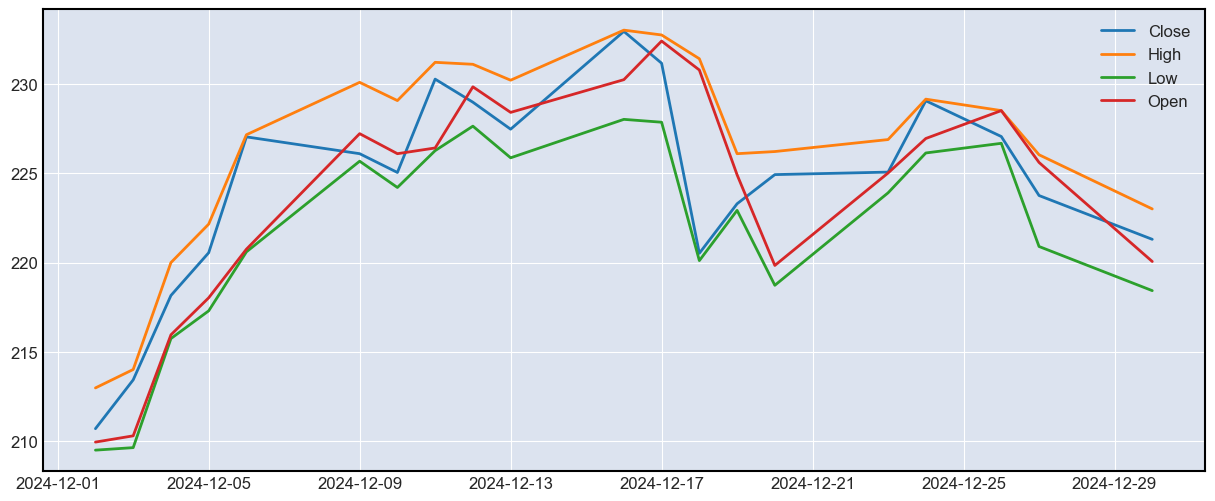

In [30]:
import matplotlib.pyplot as plt

df = df.drop("Volume", axis=1) # Volume列を削除

plt.figure(figsize=(15, 6))
plt.plot(df.index, df) # dfの全ての列をプロット
plt.legend(df)
plt.show()

In [31]:
# mplfinanceが入ってるか,またそのバージョンを確認したい。
# もし入っていなければ、インストールする。
# もし入っているが、バージョンが古い場合は、アップデートする。
# もし入っているが、バージョンが新しい場合は、何もしない。
import subprocess
import sys
import pkg_resources
import importlib
def check_and_install(package_name, required_version): 
    try:
        # パッケージがインストールされているか確認
        pkg = importlib.import_module(package_name)
        installed_version = pkg_resources.get_distribution(package_name).version
        print(f"{package_name} is already installed. Version: {installed_version}")
        
        # バージョンを比較
        if pkg_resources.parse_version(installed_version) < pkg_resources.parse_version(required_version):
            print(f"Updating {package_name} to version {required_version}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", f"{package_name}>={required_version}"])
        else:
            print(f"{package_name} is up to date.")
    except ImportError:
        print(f"{package_name} is not installed. Installing version {required_version}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", f"{package_name}>={required_version}"])
# mplfinanceのバージョンを指定
required_version = "0.12.10b0"
check_and_install("mplfinance", required_version)

mplfinance is already installed. Version: 0.12.10b0
mplfinance is up to date.


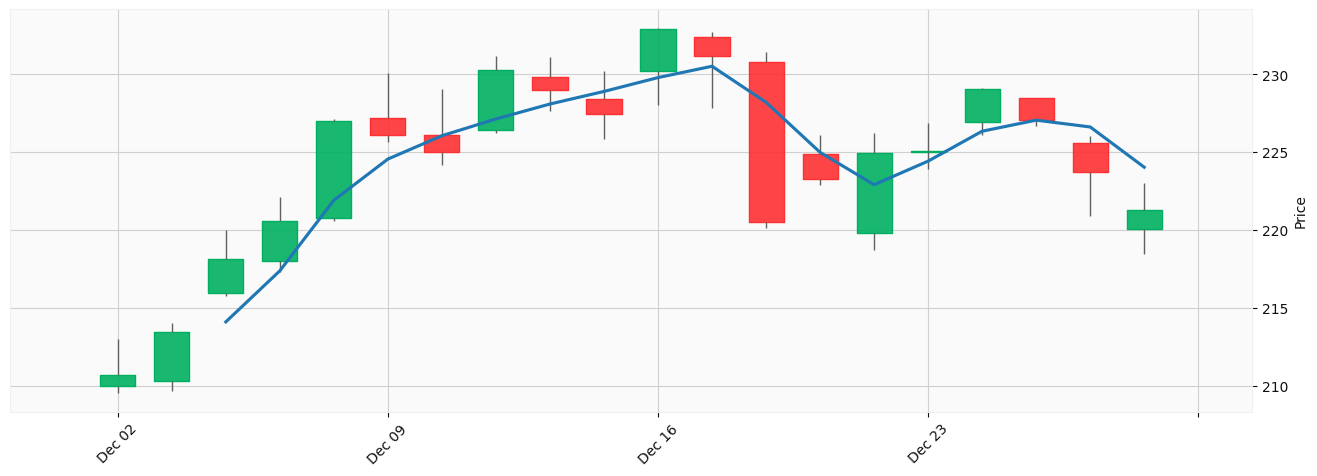

In [32]:
import mplfinance as mpf

mpf.plot(df, type="candle", figratio=(15,5), style="yahoo", mav=3) # mavは移動平均線の期間を指定する引数。今回は3日移動平均線を表示するためにmav=3と指定しています。

In [33]:
ticker = "AMZN"

df = yf.download(ticker, start="2024-12-01", end="2024-12-31", interval="1d")
df.columns = ["Close", "High", "Low", "Open", "Volume"]

[*********************100%***********************]  1 of 1 completed


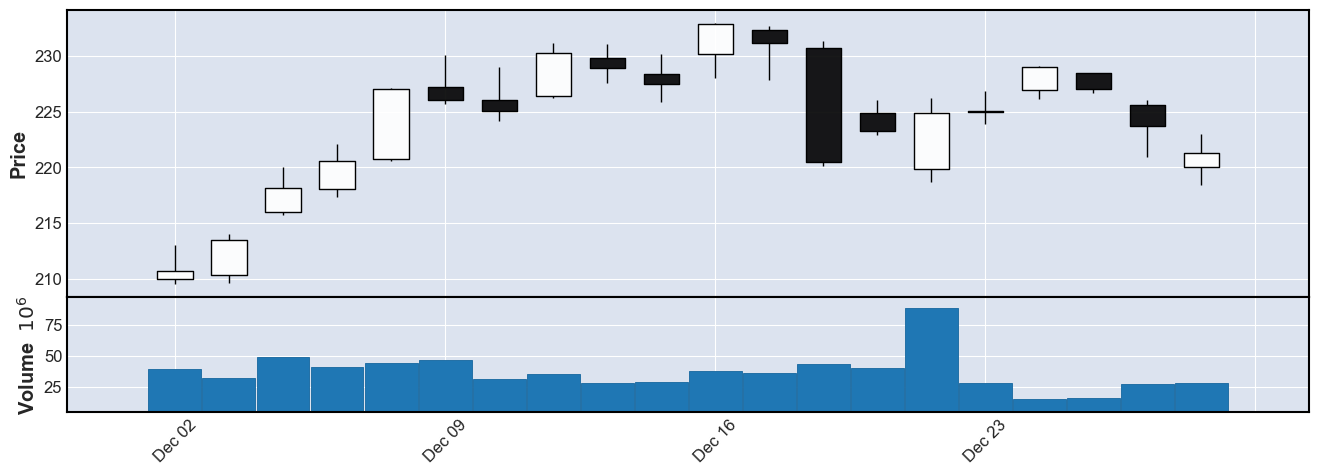

In [34]:
mpf.plot(df, type="candle", figratio=(15,5), volume=True)

In [35]:
# 移動平均線

ticker = "AMZN"

df = yf.download(ticker, start="2024-01-01", end="2024-12-31", interval="1d") # 2024年の1年間のデータを1日単位で取得
df.columns = ["Close", "High", "Low", "Open", "Volume"]

df["MA_for_5_days"] = df["Close"].rolling(window=5, min_periods=1).mean() 
# 5日移動平均線を計算するための新しい列を作成。
# rolling(window=5)は5日間の移動平均を計算することを意味
# min_periods=1は最初の数行で平均を出すためのデータが不足している場合でも平均を計算できるようにするための引数

[*********************100%***********************]  1 of 1 completed


In [36]:
df

,Close,High,Low,Open,Volume,MA_for_5_days
Date,,,,,,
2024-01-02,149.929993,152.380005,148.389999,151.539993,47339400,149.929993
2024-01-03,148.470001,151.050003,148.330002,149.199997,49425500,149.199997
2024-01-04,144.570007,147.380005,144.050003,145.589996,56039800,147.656667
2024-01-05,145.240005,146.589996,144.529999,144.690002,45153100,147.052502
2024-01-08,149.100006,149.399994,146.149994,146.740005,46757100,147.462003
...,...,...,...,...,...,...
2024-12-23,225.059998,226.880005,223.899994,225.009995,28070000,224.987997
2024-12-24,229.050003,229.139999,226.130005,226.940002,15007500,224.567999
2024-12-26,227.050003,228.500000,226.669998,228.500000,16146700,225.873999


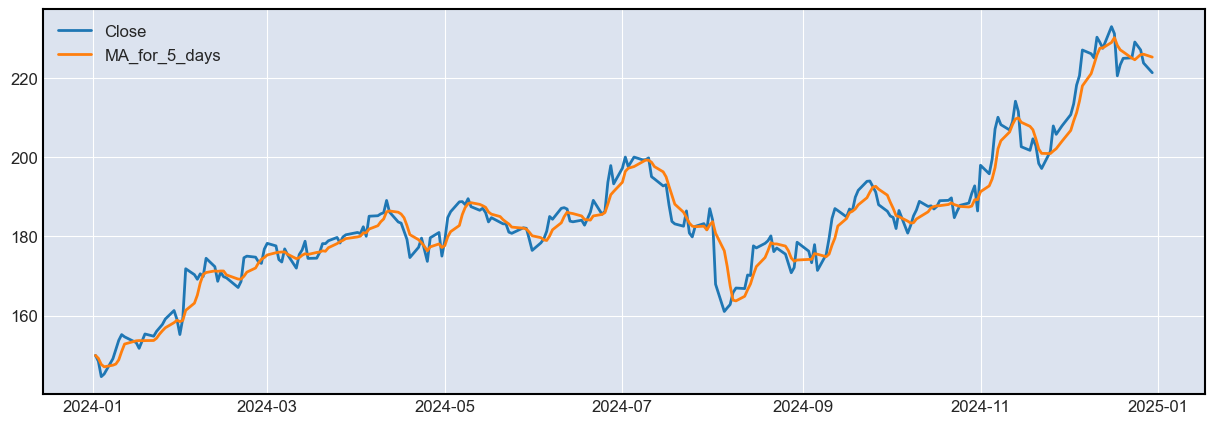

In [37]:
df_ma = df[["Close", "MA_for_5_days"]]

plt.figure(figsize=(15,5))
plt.plot(df_ma.index, df_ma)
plt.legend(df_ma)
plt.show()

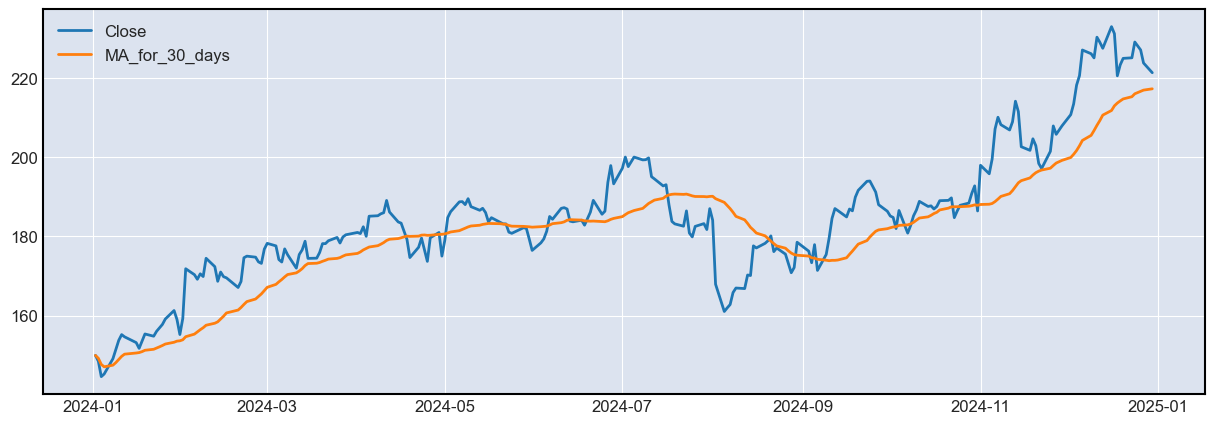

In [38]:
df["MA_for_30_days"] = df["Close"].rolling(window=30, min_periods=1).mean() # 30日移動平均線を計算するための新しい列を作成。

df_ma = df[["Close", "MA_for_30_days"]]

plt.figure(figsize=(15,5))
plt.plot(df_ma.index, df_ma)
plt.legend(df_ma)
plt.show()

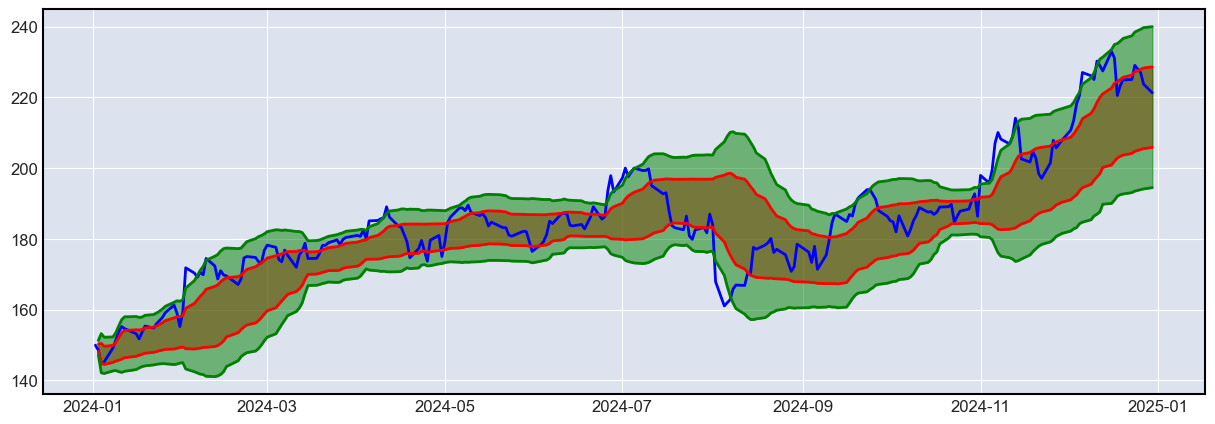

In [ ]:
# ボリンジャーバンド
# ボリンジャーバンドは、移動平均線を中心に、価格の変動範囲(標準偏差)を示すバンドを描画するテクニカル分析の手法
# 幅はどういう取引をしたいかで自分で修正する。

# df["MA_for_30_days"] = df["Close"].rolling(window=30, min_periods=1).mean()
df["std_for_30_days"] = df["Close"].rolling(window=30, min_periods=1).std() # 30日移動平均線の標準偏差を計算するための新しい列を作成。

df["-1σ"] = df["MA_for_30_days"] - 1*df["std_for_30_days"]
df["+1σ"] = df["MA_for_30_days"] + 1*df["std_for_30_days"]

df["-2σ"] = df["MA_for_30_days"] - 2*df["std_for_30_days"]
df["+2σ"] = df["MA_for_30_days"] + 2*df["std_for_30_days"]


plt.figure(figsize=(15,5))
plt.plot(df["Close"], color="blue")
plt.plot(df["-1σ"], color="red")
plt.plot(df["+1σ"], color="red")
plt.plot(df["-2σ"], color="green")
plt.plot(df["+2σ"], color="green")


plt.fill_between(df.index, df["-1σ"], df["+1σ"], color="red", alpha=0.5)
plt.fill_between(df.index, df["-2σ"], df["+2σ"], color="green", alpha=0.5)

plt.show()